In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [474]:
data = load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df["target"] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [475]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [476]:
list(df.columns)

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

In [477]:
#len(df.columns)
#len(df)
df.shape

(569, 31)

In [478]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [479]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [480]:
print(data.target_names)

['malignant' 'benign']


In [481]:
feature_cols = data.feature_names.tolist()
target_col = "target"

In [482]:
def prepare_data(feature_cols, target_col):
    """Label encode target and split into train/test."""
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )
    return X_train, X_test, y_train, y_test, le


def train_evaluate(model, X_tr, X_te, y_tr, y_te, le, model_name, cmap='Blues'):
    """Train, evaluate, print report, plot confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)

    print('=' * 55)
    print(f'  {model_name}')
    print('=' * 55)
    print(f'  Accuracy : {acc*100:.2f}%')
    print('-' * 55)
    print(classification_report(y_te, y_pred, target_names=data.target_names))

    cm   = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(8, 5))
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{model_name} | Acc: {acc*100:.2f}%')
    plt.tight_layout()
    plt.show()

    return acc

  DecisionTreeClassifier
  Accuracy : 91.23%
-------------------------------------------------------
              precision    recall  f1-score   support

   malignant       0.86      0.90      0.88        42
      benign       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



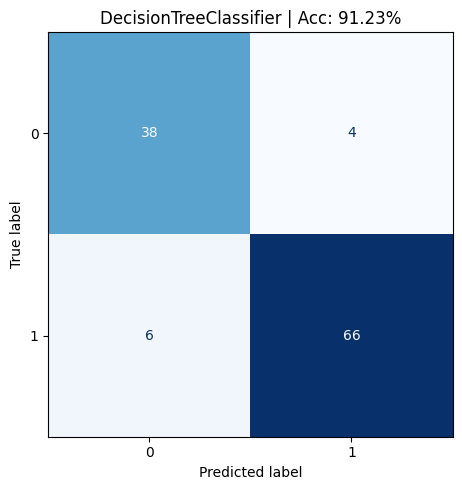

In [483]:
X_train_d, X_test_d, y_train_d, y_test_d, le_d = prepare_data(
    feature_cols,
    target_col
)
TreeModel = DecisionTreeClassifier(
    criterion="gini",
    max_depth=7,
    min_samples_leaf=4,
    min_samples_split=8,
    random_state=42
    )

Tree_accuracy= train_evaluate(TreeModel,
                                     X_train_d,X_test_d,y_train_d,y_test_d,le_d,
                                     model_name="DecisionTreeClassifier",cmap="Blues")



In [484]:
print(f"{Tree_accuracy*100:.2f}%")

91.23%


  RandomForestClassifier
  Accuracy : 95.61%
-------------------------------------------------------
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



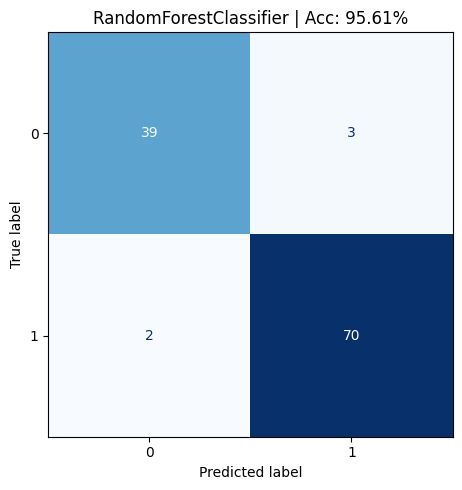

95.61%


In [485]:
x_train_r,x_test_r, y_train_r,y_test_r, le_r = prepare_data(feature_cols,target_col)

Forest = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=8,
    max_features=10,
    min_samples_leaf=4,
    min_samples_split=8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
Forest_accuracy = train_evaluate(Forest,x_train_r,x_test_r,y_train_r,y_test_r,le_r,
                                     model_name="RandomForestClassifier",cmap="Blues")

print(f"{Forest_accuracy*100:.2f}%")


  XGBClassifier
  Accuracy : 96.49%
-------------------------------------------------------
              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        42
      benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



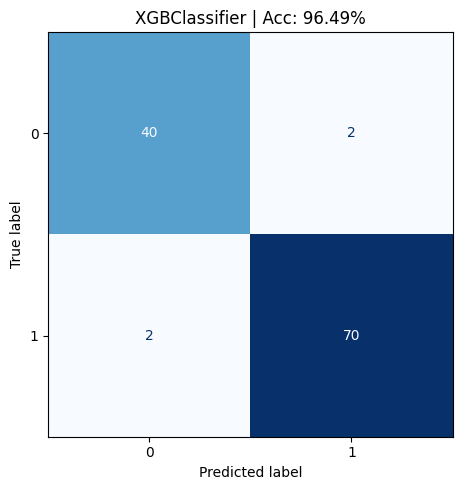

In [486]:
x_train_x,x_test_x, y_train_x,y_test_x, le_x = prepare_data(
    feature_cols,
    target_col
    )

xgb = XGBClassifier(
    n_estimators=50,
    gamma=0.5,
    learning_rate=0.09,
    reg_alpha=0.5,
    reg_lambda=1.0,
    max_depth=5,
    min_child_weight=5,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_accuracy =  train_evaluate(xgb,x_train_x,x_test_x, y_train_x,y_test_x, le_x,
                                     model_name="XGBClassifier",cmap="Blues")

In [488]:
print(f"Decision Tree accuracy : {Tree_accuracy*100:.2f}%")
print(f"Random FOrest accuracy : {Forest_accuracy*100:.2f}%")
print(f"XGBClassifier accuracy : {xgb_accuracy*100:.2f}%")

Decision Tree accuracy : 91.23%
Random FOrest accuracy : 95.61%
XGBClassifier accuracy : 96.49%


In [489]:
import joblib

In [492]:
joblib.dump(TreeModel,"Decision_Tree_Model.pkl")
joblib.dump(Forest,"Random_Forest_Model.pkl")
joblib.dump(xgb,"XGBClassifier_Model.pkl")

joblib.dump(le_d,"Decision_Tree_Le.pkl")
joblib.dump(le_r,"Random_Forest_Le.pkl")
joblib.dump(le_x,"XGBClassifier_Le.pkl")

['XGBClassifier_Le.pkl']